# ArtHeist Final Report
## VIPER Forensic Engine

This notebook is the final presentation layer for the ArtHeist submission. It focuses on the two interpretability deliverables that make the classifier legible to judges:

1. An interactive UMAP view of the learned feature space.
2. A curated Grad-CAM++ gallery showing where the model concentrates attention.

The notebook reads the shipped outputs from `results/`, `omni_export/`, and `gradcam_gallery/` so the final narrative stays tied to the actual artifacts.


In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from IPython.display import HTML, IFrame, display

ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
NOTEBOOK_DIR = ROOT / 'notebooks'
RESULTS_DIR = ROOT / 'results'
OMNI_DIR = ROOT / 'omni_export'
GRADCAM_DIR = ROOT / 'gradcam_gallery'

EVAL_METRICS_PATH = RESULTS_DIR / 'eval_metrics.json'
UMAP_FEATURES_PATH = RESULTS_DIR / 'umap_features.csv'
UMAP_HTML_PATH = OMNI_DIR / 'umap_scatter.html'
GRADCAM_FILES = sorted(GRADCAM_DIR.glob('*.png'))

assert EVAL_METRICS_PATH.exists(), f'Missing metrics file: {EVAL_METRICS_PATH}'
assert UMAP_FEATURES_PATH.exists(), f'Missing UMAP features file: {UMAP_FEATURES_PATH}'
assert UMAP_HTML_PATH.exists(), f'Missing interactive UMAP file: {UMAP_HTML_PATH}'
assert GRADCAM_FILES, f'No Grad-CAM gallery images found in {GRADCAM_DIR}'

metrics = json.loads(EVAL_METRICS_PATH.read_text(encoding='utf-8'))
umap_df = pd.read_csv(UMAP_FEATURES_PATH)

print(f'Loaded {len(umap_df)} UMAP points and {len(GRADCAM_FILES)} Grad-CAM gallery images.')

Loaded 146 UMAP points and 25 Grad-CAM gallery images.


## Evaluation Snapshot

The checkpoint is already strong enough that interpretability is now the main differentiator. The metrics below establish that the classifier is credible; the sections after that explain why its behavior is inspectable.


In [2]:
metric_specs = [
    ('Accuracy', metrics['accuracy']),
    ('F1 Score', metrics['f1']),
    ('Precision', metrics['precision']),
    ('Recall', metrics['recall']),
    ('AUC-ROC', metrics['auc_roc']),
]

card_template = (
    "<div style='flex:1; min-width:160px; background:#f7f3e8; border:1px solid #d9cfbf; "
    "border-radius:18px; padding:18px 20px;'>"
    "<div style='font-size:12px; letter-spacing:0.08em; text-transform:uppercase; color:#6b5e4a;'>{label}</div>"
    "<div style='font-size:30px; font-weight:700; color:#1f2933; margin-top:8px;'>{value:.3f}</div>"
    "</div>"
)

cards = ''.join(card_template.format(label=label, value=value) for label, value in metric_specs)
summary_html = (
    "<div style='margin:8px 0 18px 0;'>"
    f"<div style='font-size:15px; color:#4b5563; margin-bottom:14px;'>Test set size: <strong>{metrics['n_samples']}</strong> images</div>"
    f"<div style='display:flex; flex-wrap:wrap; gap:14px;'>{cards}</div>"
    "</div>"
)

display(HTML(summary_html))

## Interactive UMAP View

The UMAP projection converts the latent space into something that can be interrogated directly. Hovering over any point reveals the source filename and the model's AI confidence score, which is much more useful for live review than a static scatter plot.


In [3]:
relative_umap_html = os.path.relpath(UMAP_HTML_PATH, NOTEBOOK_DIR).replace('\\', '/')
caption_html = (
    "<div style='margin:4px 0 12px 0; color:#4b5563;'>"
    "Hover over any point to inspect the filename and confidence score. "
    "Use the Plotly toolbar to zoom into dense regions or isolate one class from the legend."
    "</div>"
)
link_html = f"<div style='margin-top:10px;'><a href='{relative_umap_html}' target='_blank'>Open the interactive UMAP in a separate tab</a></div>"

display(HTML(caption_html))
display(IFrame(src=relative_umap_html, width='100%', height=760))
display(HTML(link_html))

### Reading The Map

A polished interpretability artifact has to support actual review workflows, not just decoration.

- Cluster sanity checks: verify that real and AI examples separate into coherent regions.
- Borderline review: inspect points near the class boundary where confidence softens.
- Failure analysis: jump from suspicious filenames to Grad-CAM++ overlays and see what the model actually attended to.


## Grad-CAM++ Gallery

The gallery below pairs representative correct predictions with the harder misclassified cases. This makes it possible to compare focused, high-signal attention patterns against broader or less stable ones.


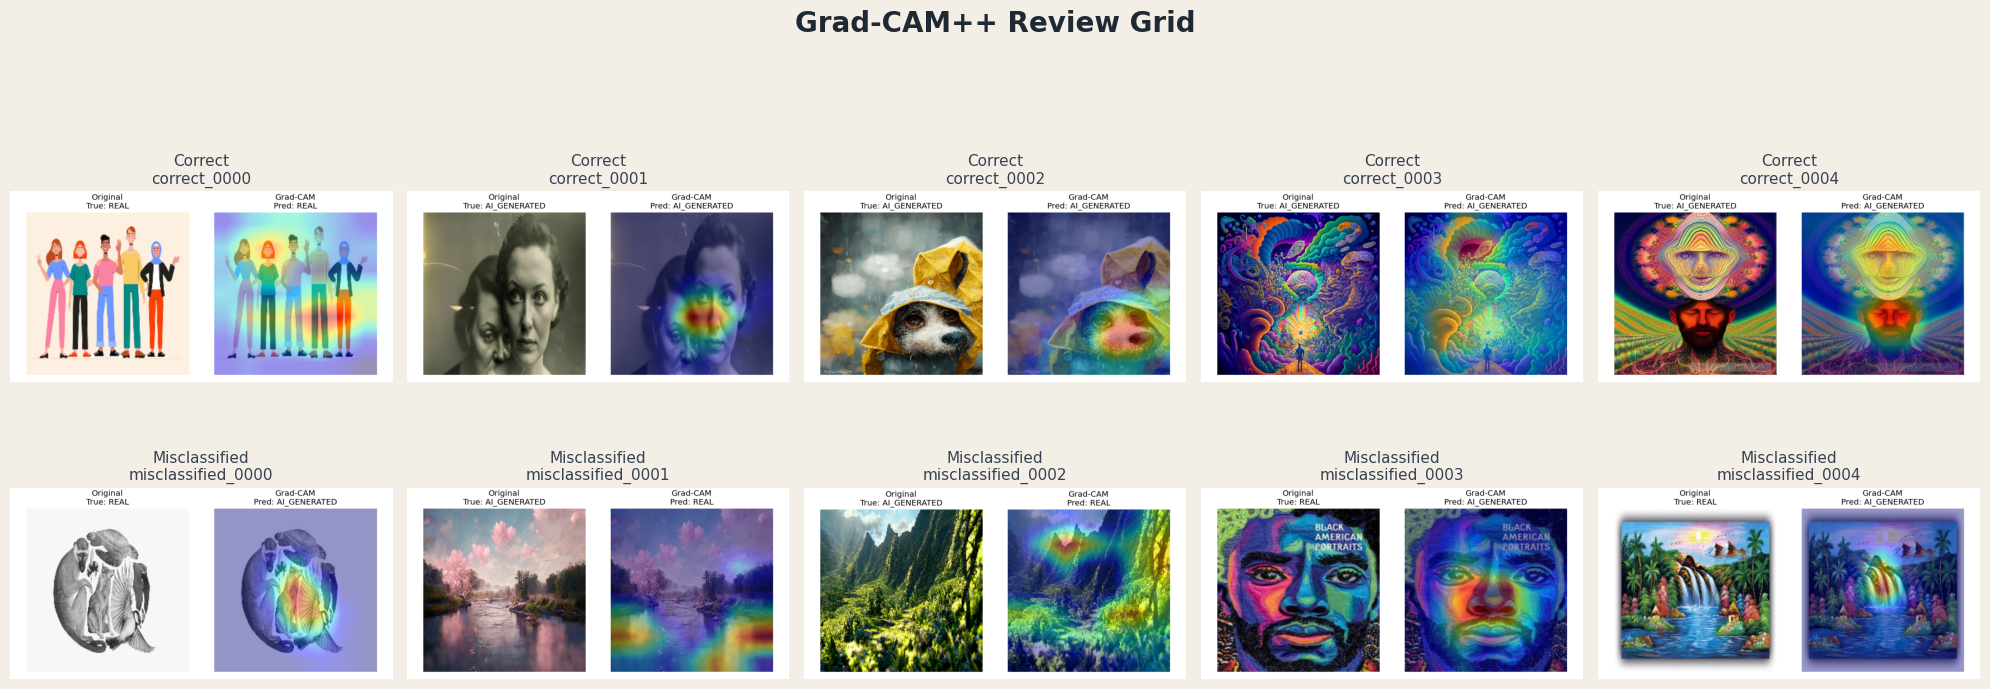

In [4]:
correct_files = sorted(GRADCAM_DIR.glob('correct_*.png'))[:5]
misclassified_files = sorted(GRADCAM_DIR.glob('misclassified_*.png'))[:5]
selected_files = correct_files + misclassified_files

rows, cols = 2, 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 8), facecolor='#f4efe6')
fig.suptitle('Grad-CAM++ Review Grid', fontsize=20, fontweight='bold', color='#1f2933', y=0.98)

for ax, image_path in zip(axes.flat, selected_files):
    image = Image.open(image_path).convert('RGB')
    ax.imshow(image)
    title_prefix = 'Correct' if image_path.name.startswith('correct_') else 'Misclassified'
    ax.set_title(f"{title_prefix}\n{image_path.stem}", fontsize=11, color='#374151')
    ax.axis('off')

for ax in axes.flat[len(selected_files):]:
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Grad-CAM++ Takeaways

The strongest overlays usually lock onto fine texture, edge transitions, and localized regions where synthetic generation often looks inconsistent. The weaker cases spread attention more broadly, which is exactly the kind of behavior a judge should be able to inspect before trusting a prediction.


In [5]:
artifact_table = pd.DataFrame([
    {
        'Artifact': 'Interactive UMAP HTML',
        'Path': str(UMAP_HTML_PATH.relative_to(ROOT)),
        'Exists': UMAP_HTML_PATH.exists(),
    },
    {
        'Artifact': 'UMAP feature table',
        'Path': str(UMAP_FEATURES_PATH.relative_to(ROOT)),
        'Exists': UMAP_FEATURES_PATH.exists(),
    },
    {
        'Artifact': 'Grad-CAM gallery directory',
        'Path': str(GRADCAM_DIR.relative_to(ROOT)),
        'Exists': GRADCAM_DIR.exists(),
    },
    {
        'Artifact': 'Evaluation metrics JSON',
        'Path': str(EVAL_METRICS_PATH.relative_to(ROOT)),
        'Exists': EVAL_METRICS_PATH.exists(),
    },
])

artifact_table

,Artifact,Path,Exists
0,Interactive UMAP HTML,omni_export\umap_scatter.html,True
1,UMAP feature table,results\umap_features.csv,True
2,Grad-CAM gallery directory,gradcam_gallery,True
3,Evaluation metrics JSON,results\eval_metrics.json,True


## Closing Note

This notebook is intentionally presentation-oriented. Training, feature extraction, and artifact generation happen elsewhere in the pipeline; the job here is to make the final model inspectable, defensible, and easy to demonstrate live.
